In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adata = sc.read_h5ad('workspace/hpca/hpca_downstream/Final_Embedding_Healthy/final_embedding_healthy.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 815126 × 20
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500

In [4]:
adata.obsm['X_umap'] = adata.obsm['UMAP_scanvi_global_lineage'].copy()
adata.obsp['connectivities'] = adata.obsp['scanvi_neighbors_global_lineage_connectivities'].copy()
adata.obsp['distances'] = adata.obsp['scanvi_neighbors_global_lineage_distances'].copy()
adata.uns['neighbors'] = adata.uns['scanvi_neighbors_global_lineage'].copy()

In [5]:
sc.set_figure_params(dpi=100, figsize=(5,5), dpi_save=300, frameon=False)

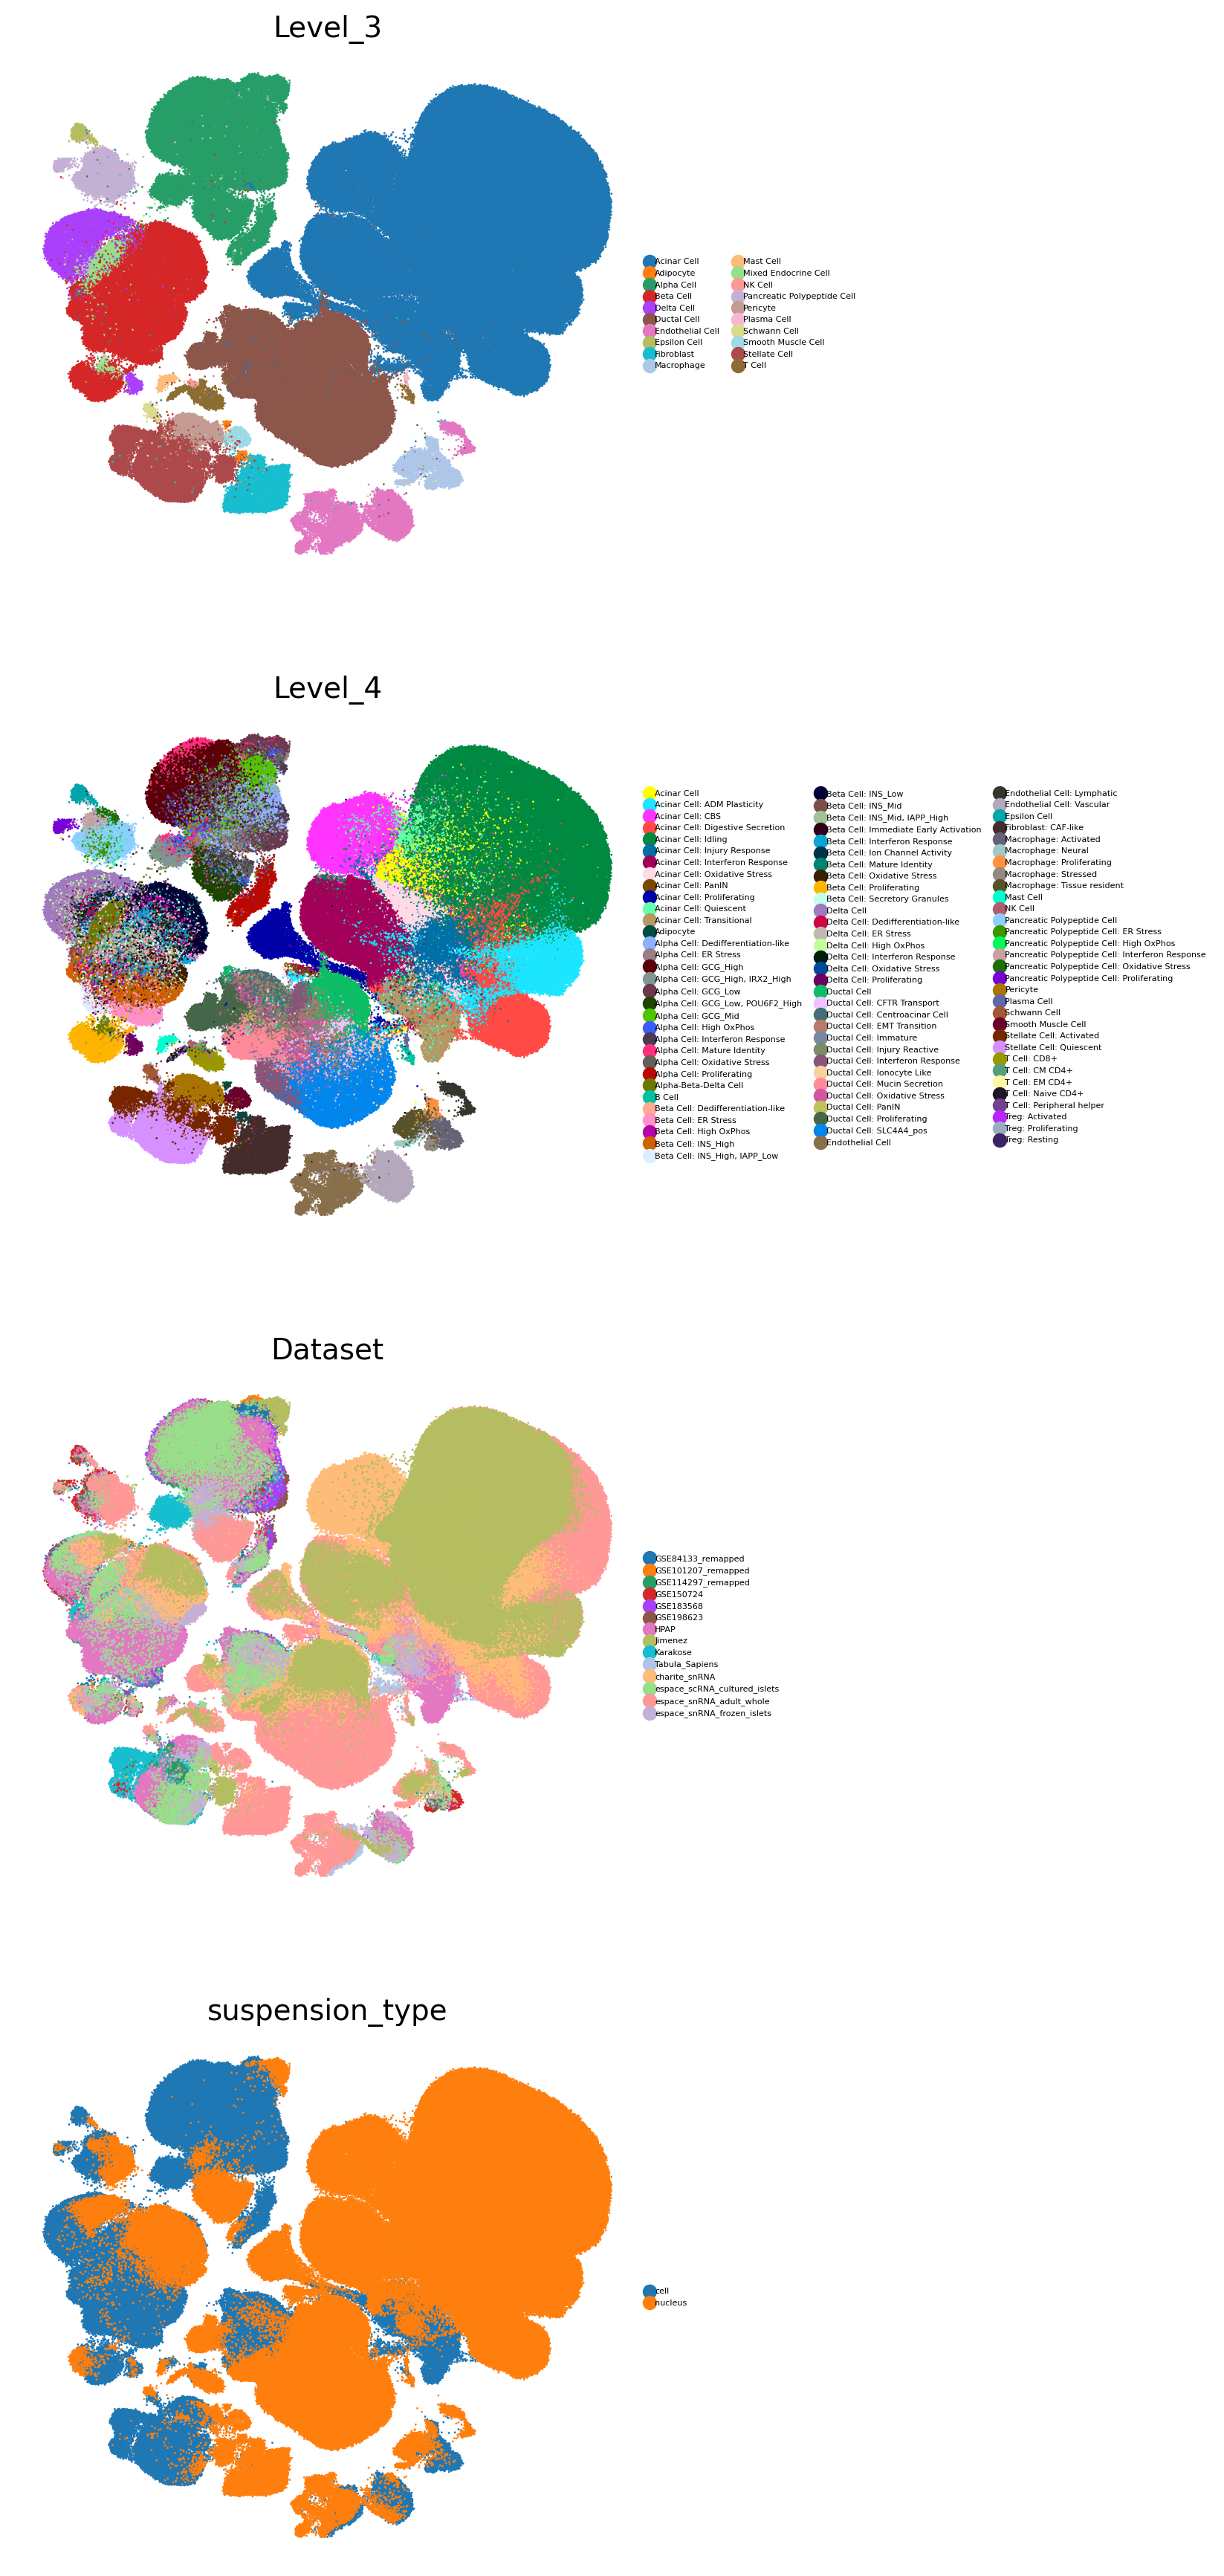

In [6]:
sc.pl.umap(adata, color=['Level_3', 'Level_4', 'Dataset', 'suspension_type'], ncols=1, legend_fontsize=4, size=4)

In [7]:
adata.obs.groupby('Dataset')['donor_id'].nunique()

/tmp/ipykernel_3396741/970247530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Dataset')['donor_id'].nunique()


Dataset
GSE84133_remapped                4
GSE101207_remapped               6
GSE114297_remapped              12
GSE150724                        3
GSE183568                        5
GSE198623                        5
HPAP                            27
Jimenez                         11
Karakose                         6
Tabula_Sapiens                   2
charite_snRNA                    3
espace_scRNA_cultured_islets     5
espace_snRNA_adult_whole        16
espace_snRNA_frozen_islets       4
Name: donor_id, dtype: int64

In [8]:
for ds in adata.obs['Dataset'].unique():
    adata_ds = adata[adata.obs['Dataset'] == ds]
    print(f"{ds}: X.max() = {adata_ds.X.max()}")

GSE101207_remapped: X.max() = 8.807812690734863
GSE198623: X.max() = 6.624307632446289
GSE84133_remapped: X.max() = 8.21654987335205
GSE183568: X.max() = 6.21156120300293
Karakose: X.max() = 9.017743110656738
Tabula_Sapiens: X.max() = 9.14294719696045
GSE150724: X.max() = 6.01026725769043
GSE114297_remapped: X.max() = 8.415139198303223
HPAP: X.max() = 8.292338371276855
espace_scRNA_cultured_islets: X.max() = 9.175793647766113
espace_snRNA_frozen_islets: X.max() = 8.397671699523926
espace_snRNA_adult_whole: X.max() = 9.83256721496582
charite_snRNA: X.max() = 6.9418535232543945
Jimenez: X.max() = 8.913110733032227


In [9]:
adata_counts = sc.read_h5ad('workspace/hpca/hpca_downstream/2026_final_object_healthy.h5ad')

In [11]:
# Copy obs, obsp, uns, and obsm from adata to adata_counts
adata_counts.obs = adata.obs.copy()
adata_counts.obsm = adata.obsm.copy()
adata_counts.obsp = adata.obsp.copy()
adata_counts.uns = adata.uns.copy()
adata_counts.obsm['X_scanvi'] = adata.X.copy()

In [12]:
adata_counts

AnnData object with n_obs × n_vars = 815126 × 24600
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

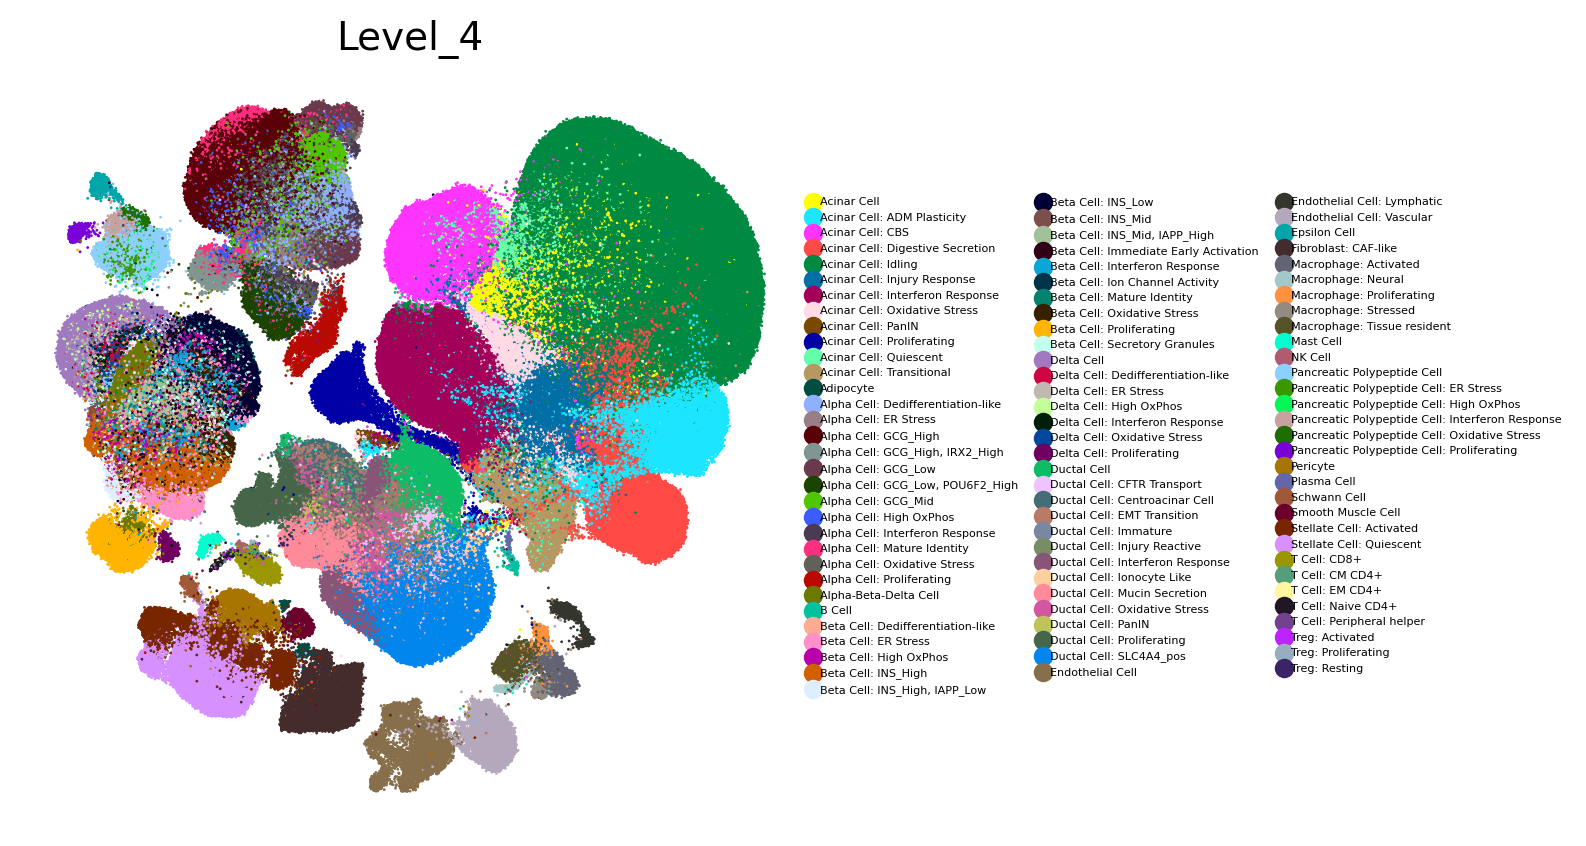

In [13]:
sc.pl.umap(adata_counts, color=['Level_4'], ncols=1, legend_fontsize=4, size=4)

In [16]:
adata_counts.write('workspace/2026_final_object_healthy.h5ad')